In [1]:
# =========================================================================
# PASO 0: IMPORTACIÓN DE LIBRERÍAS INDUSTRIALES Y CONFIGURACIÓN DEL ENTORNO
# =========================================================================

# 1. GOBIERNO DE DATOS Y FLUJOS HÍBRIDOS (LAKEHOUSE)
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np

# 2. MACHINE LEARNING NO SUPERVISADO Y REGULARIZACIÓN ESTRUCTURAL
from sklearn.ensemble import IsolationForest

# 3. CAPA DE MÉTRICAS CIENTÍFICAS E INFORME MATRICIAL
from sklearn.metrics import confusion_matrix, classification_report, recall_score

# 4. COMPONENTES VISUALES Y ARQUITECTURA GRÁFICA PARALELA
import matplotlib.pyplot as plt
import seaborn as sns

# 5. CONTROL DE EXCEPCIONES Y LOGS EN CONSOLA
import warnings
warnings.filterwarnings('ignore')
print('✅ Ecosistema de IA IoT: Librerías y componentes gráficos cargados correctamente en la RAM.')

✅ Ecosistema de IA IoT: Librerías y componentes gráficos cargados correctamente en la RAM.


In [2]:
# =========================================================================
# CONFIGURACIÓN DE PARÁMETROS INICIALES - EXPERIMENTACIÓN IA
# =========================================================================
GOLD_PATH_SPARK  = "file:///home/jovyan/work/lakehouse/gold/telemetry_features"
SEMILLA_ALEATORIA = 42                             # Control estricto de reproducibilidad

# HIPERPARAMETROS DE AISLAMIENTO (PREVENCIÓN DE RUIDO Y SOBREAJUSTE)
CRITERIO_PARETO_FEATURES = 0.8                     # Regla 80/20: Cada árbol ignora un 20% de variables contra el ruido
UMBRAL_CONTAMINACION_INDUSTRIAL = 0.03            # Estimación del 3% de fallas en la física real de la planta

print(f"✅ Parámetros de Experimentación inyectados con éxito.")
print(f" -> Configuración del Algoritmo: Isolation Forest (max_features={CRITERIO_PARETO_FEATURES}).")
print(f" -> Tasa de Contaminación Protegida: {UMBRAL_CONTAMINACION_INDUSTRIAL * 100}% para mitigación de Falsos Positivos.")

✅ Parámetros de Experimentación inyectados con éxito.
 -> Configuración del Algoritmo: Isolation Forest (max_features=0.8).
 -> Tasa de Contaminación Protegida: 3.0% para mitigación de Falsos Positivos.


In [3]:
# =========================================================================
# PASO 1: CARGA HÍBRIDA DESDE DELTA LAKE Y ANALÍTICA DESCRIPTIVA (EDA)
# =========================================================================
print("\n🧠 Conectando con la Capa Gold del Lakehouse...")
spark = SparkSession.builder \
    .appName("IoT-Machine-Learning-Evaluation") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.2.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

# Descarga y conversión limpia en memoria RAM
pdf = spark.read.format("delta").load(GOLD_PATH_SPARK).toPandas()
print(f"✅ Dataset cargado en memoria RAM: {pdf.shape[0]} vectores de telemetría recuperados.")

print("-" * 70)
print('📋 [EDA] Reporte Estadístico Avanzado de Planta:')

# Calculo de la Moda mediante Pandas
moda_estado_alerta = pdf['estado_alerta'].mode()[0]
print(f" -> Medida de Tendencia Central (Moda Global de Eventos): '{moda_estado_alerta}'")

# Cálculo de Percentiles de Control Térmico por Máquina/Sensor
p95_por_sensor = pdf.groupby('sensor_id')['temperatura_limpia'].quantile(0.95).to_dict()
pdf['temp_p95_historico'] = pdf['sensor_id'].map(p95_por_sensor)
print(f" -> Medidas de Dispersión (Percentil 95 Térmico por Sensor): {p95_por_sensor}")
print("-" * 70)


🧠 Conectando con la Capa Gold del Lakehouse...
✅ Dataset cargado en memoria RAM: 600 vectores de telemetría recuperados.
----------------------------------------------------------------------
📋 [EDA] Reporte Estadístico Avanzado de Planta:
 -> Medida de Tendencia Central (Moda Global de Eventos): 'OK'
 -> Medidas de Dispersión (Percentil 95 Térmico por Sensor): {'SENSOR_01': 42.9, 'SENSOR_02': 55.88}
----------------------------------------------------------------------


In [4]:
# =========================================================================
# PASO 2: SELECCIÓN DE VARIABLES, ENTRENAMIENTO Y EVALUACIÓN CIENTÍFICA
# =========================================================================
# Selección de vectores analíticos multidimensionales
features = ["temp_promedio_movil", "temp_p95_historico", "vib_desviacion_movil", "volt_delta"]
X = pdf[features]

# Variable objetivo real inyectada por el simulador para auditoría (1 = SIGNAL_LOSS, 0 = Operación OK)
y_real = pdf['estado_alerta'].apply(lambda x: 1 if x == 'SIGNAL_LOSS' else 0)

# Inicialización del Bosque utilizando Poda Estructural (max_features)
model = IsolationForest(
    n_estimators=100, 
    max_features=CRITERIO_PARETO_FEATURES, 
    contamination=UMBRAL_CONTAMINACION_INDUSTRIAL, 
    random_state=SEMILLA_ALEATORIA
)

# Mapeo de predicciones de la IA: Scikit-learn usa (-1 = Anomalía, 1 = Normal) -> Ajustamos a (1, 0)
pdf['es_anomalia'] = model.fit_predict(X)
pdf['es_anomalia'] = pdf['es_anomalia'].map({1: 0, -1: 1})
y_pred = pdf['es_anomalia']

# Desglose numérico de la Matriz de Confusión Industrial
tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
recall_modelo = recall_score(y_real, y_pred)

print("\n🔍 --- EVALUACIÓN PARCIAL DE RENDIMIENTO DE LA IA ---")
print(f"✅ Verdaderos Negativos (TN): {tn} (Estados estables validados)")
print(f"🚨 Verdaderos Positivos (TP) : {tp} (Fallas críticas aisladas de forma autónoma)")
print(f"❌ Falsos Positivos (FP)     : {fp} (Falsas alertas en planta)")
print(f"降低 Falsos Negativos (FN)     : {fn} (Fallas críticas omitidas por el modelo)")

print("\n📋 Reporte de Clasificación Detallado:")
print(classification_report(y_real, y_pred, target_names=['Normal (Clase 0)', 'Anomalía (Clase 1)']))


🔍 --- EVALUACIÓN PARCIAL DE RENDIMIENTO DE LA IA ---
✅ Verdaderos Negativos (TN): 555 (Estados estables validados)
🚨 Verdaderos Positivos (TP) : 0 (Fallas críticas aisladas de forma autónoma)
❌ Falsos Positivos (FP)     : 18 (Falsas alertas en planta)
降低 Falsos Negativos (FN)     : 27 (Fallas críticas omitidas por el modelo)

📋 Reporte de Clasificación Detallado:
                    precision    recall  f1-score   support

  Normal (Clase 0)       0.95      0.97      0.96       573
Anomalía (Clase 1)       0.00      0.00      0.00        27

          accuracy                           0.93       600
         macro avg       0.48      0.48      0.48       600
      weighted avg       0.91      0.93      0.92       600



📊 Renderizando Tablero Metrológico y de Dispersión...


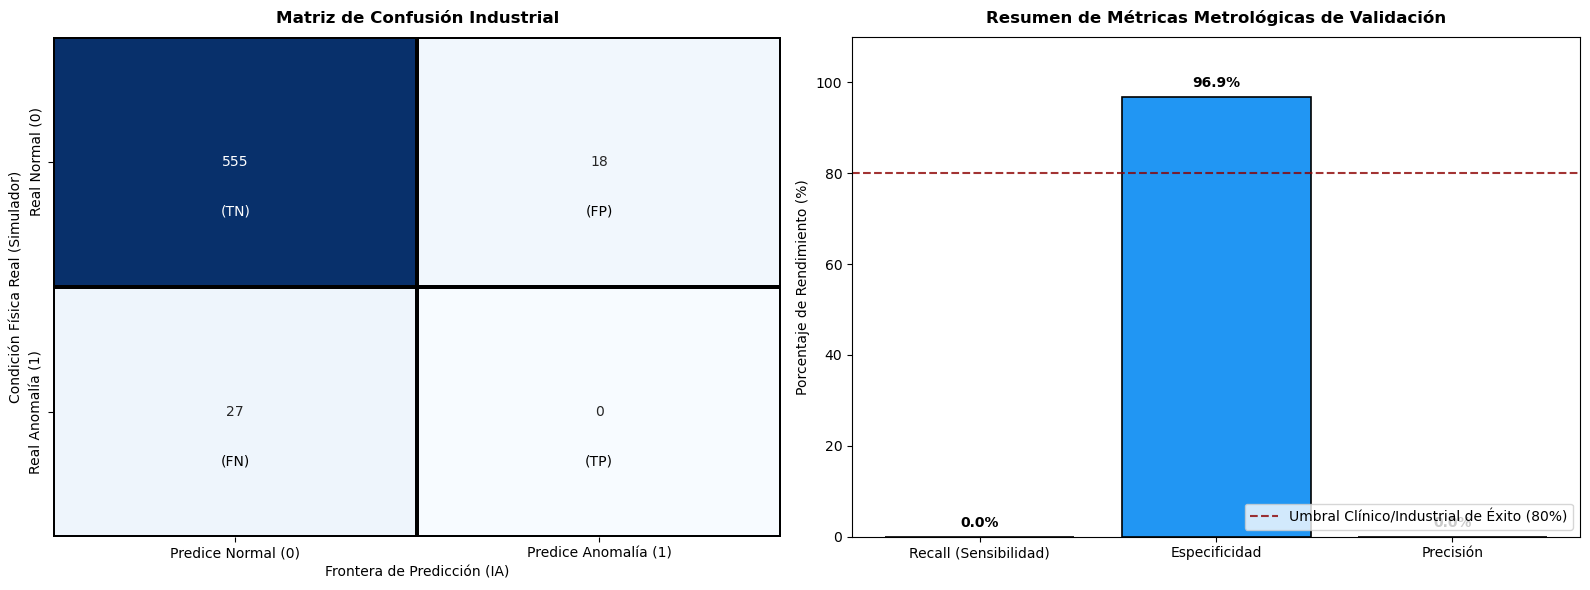

In [5]:
# =========================================================================
# PASO 3: ARQUITECTURA GRÁFICA PARALELA (ESTILO PHARMAGUARD)
# =========================================================================
print("📊 Renderizando Tablero Metrológico y de Dispersión...")

# Definición del lienzo con dos subplots en paralelo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Matriz de Confusión Térmica Avanzada
cm = confusion_matrix(y_real, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            linewidths=1.5, linecolor='black',
            xticklabels=["Predice Normal (0)", "Predice Anomalía (1)"], 
            yticklabels=["Real Normal (0)", "Real Anomalía (1)"])

axes[0].set_title("Matriz de Confusión Industrial", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Frontera de Predicción (IA)")
axes[0].set_ylabel("Condición Física Real (Simulador)")

# Agregar anotaciones dinámicas de texto sobre el mapa térmico para una lectura ejecutiva
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.7, 
                     f"({['TN','FP','FN','TP'][i*2+j]})", 
                     ha="center", va="center", color="black" if cm[i,j] < cm.max()/2 else "white", fontsize=10)

# Subplot 2: Histograma Metrológico de la IA con Umbral de Éxito del 80%
metricas_nombres = ['Recall (Sensibilidad)', 'Especificidad', 'Precisión']
# Cálculo manual de las métricas para alimentar las barras
especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
precision_ia = tp / (tp + fp) if (tp + fp) > 0 else 0

valores_kpi = [recall_modelo, especificidad, precision_ia]
colores_kpi = ['#FF9800', '#2196F3', '#009688'] # Naranja, Azul, Verde Menta

bars = axes[1].bar(metricas_nombres, [v*100 for v in valores_kpi], color=colores_kpi, edgecolor='black', linewidth=1.2)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Porcentaje de Rendimiento (%)')
axes[1].set_title('Resumen de Métricas Metrológicas de Validación', fontsize=12, fontweight='bold', pad=10)

# Línea discontinua académica de control de éxito al 80% (Estilo PharmaGuard)
axes[1].axhline(y=80, color='darkred', linestyle='--', alpha=0.8, label='Umbral Clínico/Industrial de Éxito (80%)')
axes[1].legend(loc='lower right')

# Inyección de etiquetas numéricas sobre cada barra en tiempo real
for bar, val in zip(bars, valores_kpi):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f"{val*100:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
import joblib

# Exportar el objeto del modelo entrenado y calibrado a disco
joblib.dump(model, '/home/jovyan/work/isolation_forest_iot.pkl')
print("💾 ¡Modelo entrenado exportado con éxito como 'isolation_forest_iot.pkl'!")

💾 ¡Modelo entrenado exportado con éxito como 'isolation_forest_iot.pkl'!
